https://www.kaggle.com/datasets/devashishmani1/pain-prediction-dataset-emphatica-e4

# **Conjunto de dados de previsão de dor Emphatica E4**

**Conjunto de dados de séries temporais fisiológicas que pode ser usado para previsão da dor.**

# Sobre o conjunto de dados

Este conjunto de dados compreende sinais fisiológicos e de movimento multimodais coletados usando um dispositivo vestível Empatica, projetado para analisar e prever os níveis subjetivos de dor em indivíduos. Os dados são registrados em formato de série temporal, onde cada linha representa leituras sincronizadas dos sensores, capturadas em intervalos de tempo específicos para um determinado indivíduo.

O conjunto de dados inclui sinais fisiológicos e características baseadas em movimento, permitindo uma compreensão abrangente do estado físico e emocional do usuário.

**Funcionalidades incluídas:**

person_ID → Identificador único para cada sujeito

acc_x, acc_y, acc_z → Captura de dados do acelerômetro de 3 eixos para registro do movimento corporal

EDA (Atividade Eletrodérmica) → Mede a condutância da pele, indicando estresse e excitação emocional.

bvp (Pulso de Volume Sanguíneo) → Reflete a atividade cardiovascular e as alterações do fluxo sanguíneo.

hr (Frequência Cardíaca) → Batimentos por minuto, indicando a resposta fisiológica

temp (Temperatura da Pele) → Fornece informações sobre a temperatura corporal periférica

pain_scale → Classificação subjetiva da dor relatada pelo indivíduo (ex.: escala de 0 a 10)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('pain_dataset_200P_4hz.csv')

# EAD

In [2]:
#Visualizando as primeiras linhas e informações gerais
print(df.info())
print(df.describe())

#Verificar se há valores ausentes
print(f"\nValores nulos:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_ID   96000 non-null  object 
 1   acc_x       96000 non-null  float64
 2   acc_y       96000 non-null  float64
 3   acc_z       96000 non-null  float64
 4   eda         96000 non-null  float64
 5   bvp         96000 non-null  float64
 6   hr          96000 non-null  float64
 7   temp        96000 non-null  float64
 8   pain_scale  96000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.6+ MB
None
              acc_x         acc_y         acc_z           eda           bvp  \
count  96000.000000  96000.000000  96000.000000  96000.000000  96000.000000   
mean       0.000359     -0.005374      0.005558      2.890202     86.924307   
std        0.274042      0.274731      0.274240      2.151289     26.516553   
min       -1.249800     -1.025200     -1.211600      0.050

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2712446259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pain_scale', data=df, palette='viridis')


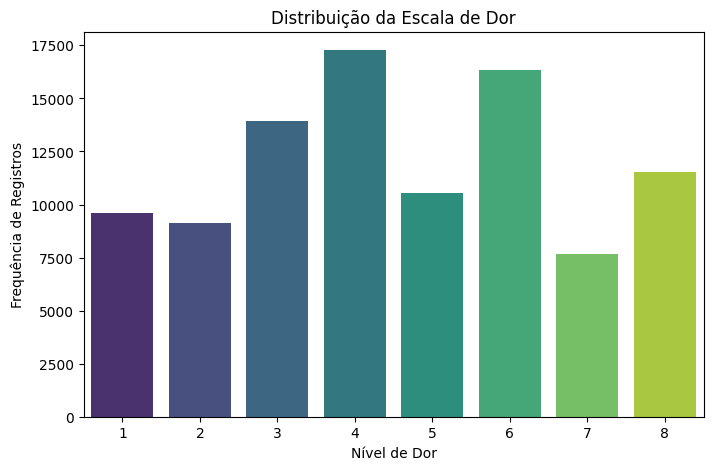

In [3]:
#Distribuição da Variável Alvo (pain_scale)
plt.figure(figsize=(8, 5))
sns.countplot(x='pain_scale', data=df, palette='viridis')
plt.title('Distribuição da Escala de Dor')
plt.xlabel('Nível de Dor')
plt.ylabel('Frequência de Registros')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2561836203.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='pain_scale', y='hr', data=df, palette='Set2')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2561836203.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='pain_scale', y='eda', data=df, palette='flare')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2561836203.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='pain_scale', y='temp', data=df, palette='crest')


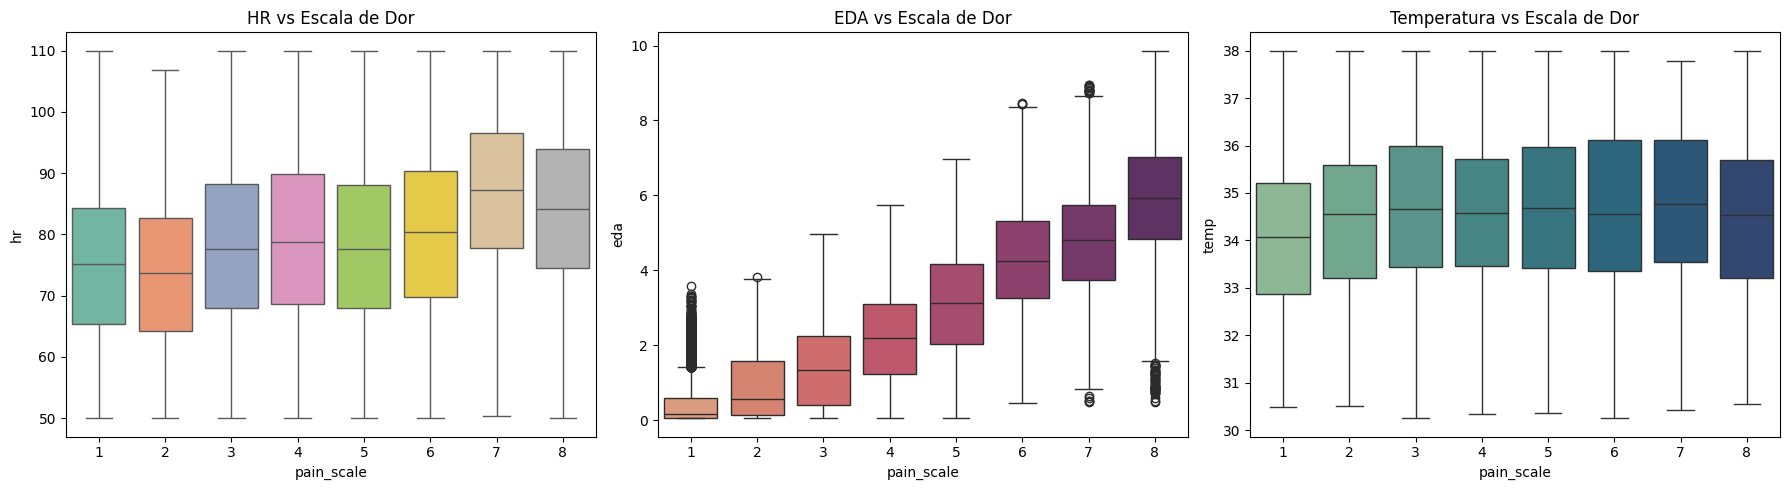

In [4]:
#Análise de Sinais Fisiológicos por Dor
#Variáveis como Frequência Cardíaca (HR), Atividade Eletrodérmica (EDA) e Temperatura se comportam conforme a dor aumenta.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Correlacionando HR com Dor
sns.boxplot(ax=axes[0], x='pain_scale', y='hr', data=df, palette='Set2')
axes[0].set_title('HR vs Escala de Dor')

#Correlacionando EDA (Sudorese) com Dor
sns.boxplot(ax=axes[1], x='pain_scale', y='eda', data=df, palette='flare')
axes[1].set_title('EDA vs Escala de Dor')

#Correlacionando Temperatura com Dor
sns.boxplot(ax=axes[2], x='pain_scale', y='temp', data=df, palette='crest')
axes[2].set_title('Temperatura vs Escala de Dor')

plt.tight_layout()
plt.show()

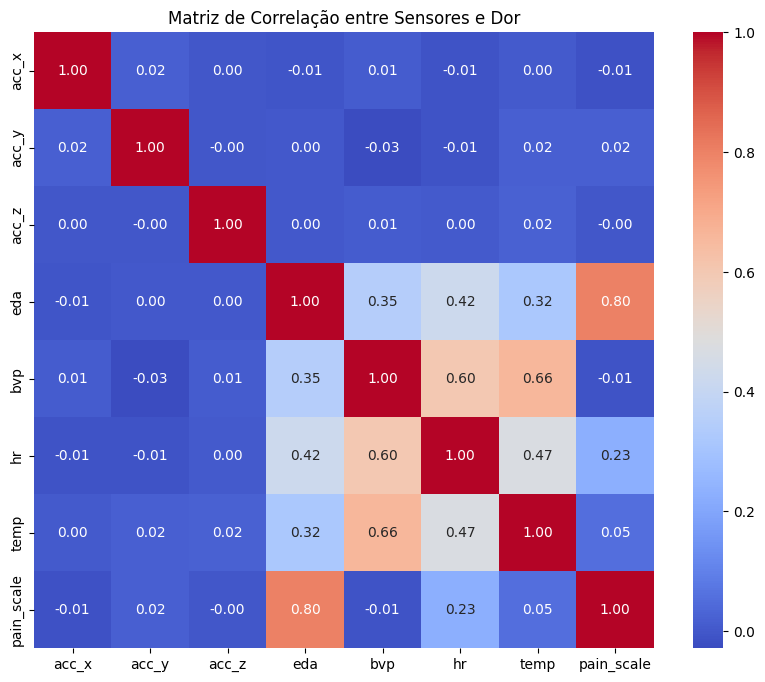

In [5]:
#Matriz de Correlação
plt.figure(figsize=(10, 8))
#Selecionando apenas colunas numéricas para a correlação
corr = df.drop(columns=['person_ID']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre Sensores e Dor')
plt.show()

# Análise de Movimento (Acelerômetro)

# $$Magnitude = \sqrt{acc\_x^2 + acc\_y^2 + acc\_z^2}$$

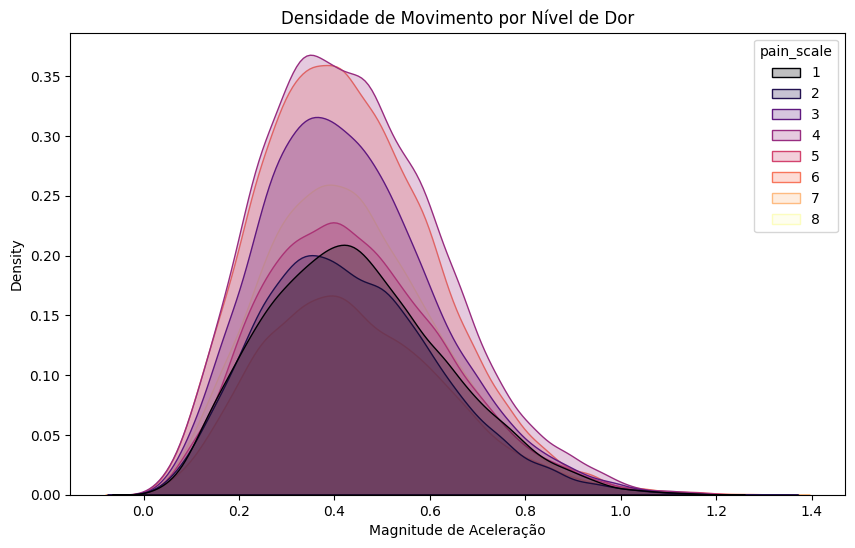

In [6]:
#Análise de Movimento (Acelerômetro)
#Muitas vezes, a dor gera agitação motora. Podemos calcular a magnitude do acelerômetro para ver se há correlação com o estresse/dor.
#Calculando a magnitude do movimento
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='acc_mag', hue='pain_scale', fill=True, palette='magma')
plt.title('Densidade de Movimento por Nível de Dor')
plt.xlabel('Magnitude de Aceleração')
plt.show()

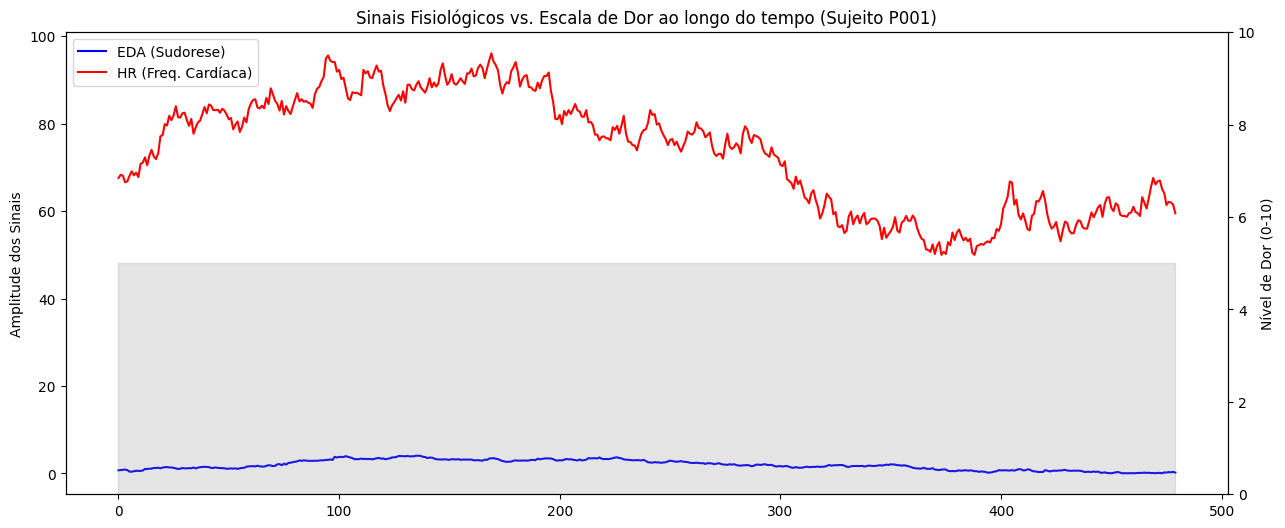

In [7]:
#Visualização do Sinal Contínuo
#Filtrar apenas um paciente para visualização clara (ex: P001)
subject = df[df['person_ID'] == 'P001'].reset_index()

fig, ax1 = plt.subplots(figsize=(15, 6))

#Eixo 1: Sinais Fisiológicos (EDA e HR)
ax1.plot(subject.index, subject['eda'], color='blue', label='EDA (Sudorese)')
ax1.plot(subject.index, subject['hr'], color='red', label='HR (Freq. Cardíaca)')
ax1.set_ylabel('Amplitude dos Sinais')
ax1.legend(loc='upper left')

#Eixo 2: Escala de Dor (Sobreposta)
ax2 = ax1.twinx()
ax2.fill_between(subject.index, subject['pain_scale'], color='gray', alpha=0.2, label='Escala de Dor')
ax2.set_ylabel('Nível de Dor (0-10)')
ax2.set_ylim(0, 10)

plt.title('Sinais Fisiológicos vs. Escala de Dor ao longo do tempo (Sujeito P001)')
plt.show()

In [8]:
#Engenharia de Recursos (Feature Engineering)
#Criando janelas de 1 segundo (como a freq é 4Hz, a janela é de 4 linhas)
window_size = 4 

#Média móvel para suavizar ruídos do BVP e EDA
df['eda_smooth'] = df.groupby('person_ID')['eda'].transform(lambda x: x.rolling(window_size).mean())
df['hr_std'] = df.groupby('person_ID')['hr'].transform(lambda x: x.rolling(window_size).std())

#Preencher NaNs criados pela janela móvel
df.fillna(method='bfill', inplace=True)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2160049440.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [9]:
#Análise de Correlação com Lag (Atraso)
#Na fisiologia, a dor nem sempre altera o sinal instantaneamente. Pode haver um atraso (lag).
#Verificar a correlação da Dor com o sinal de EDA "atrasado" em 2 segundos (8 frames)
df['eda_lagged'] = df.groupby('person_ID')['eda'].shift(8)

correlation = df[['pain_scale', 'eda', 'eda_lagged', 'hr', 'temp']].corr()
print("Correlação com Lag:\n", correlation['pain_scale'])

Correlação com Lag:
 pain_scale    1.000000
eda           0.802903
eda_lagged    0.802530
hr            0.225624
temp          0.052561
Name: pain_scale, dtype: float64


In [10]:
#Distribuição de Frequência (Análise Espectral)
from scipy.signal import welch

#Normalização: Foca na variação interna de cada pessoa, não na diferença entre pessoas
cols_sensores = ['eda', 'bvp', 'hr', 'temp', 'acc_x', 'acc_y', 'acc_z']
for col in cols_sensores:
    df[f'{col}_norm'] = df.groupby('person_ID')[col].transform(lambda x: (x - x.mean()) / x.std())

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


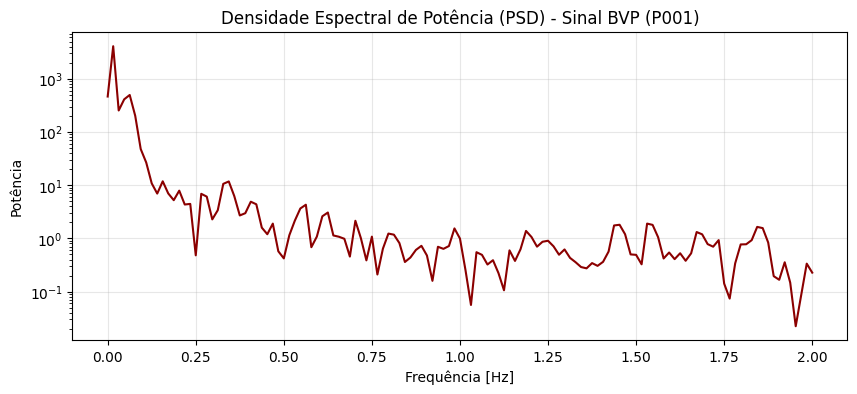

In [11]:
#Correção do Erro: Análise de Frequência (Welch)
#Selecionando um sujeito para análise
sujeito_exemplo = df[df['person_ID'] == 'P001']

f, Pxx_den = welch(sujeito_exemplo['bvp'].values, fs=4)

plt.figure(figsize=(10, 4))
plt.semilogy(f, Pxx_den, color='darkred')
plt.title('Densidade Espectral de Potência (PSD) - Sinal BVP (P001)')
plt.xlabel('Frequência [Hz]')
plt.ylabel('Potência')
plt.grid(True, alpha=0.3)
plt.show()

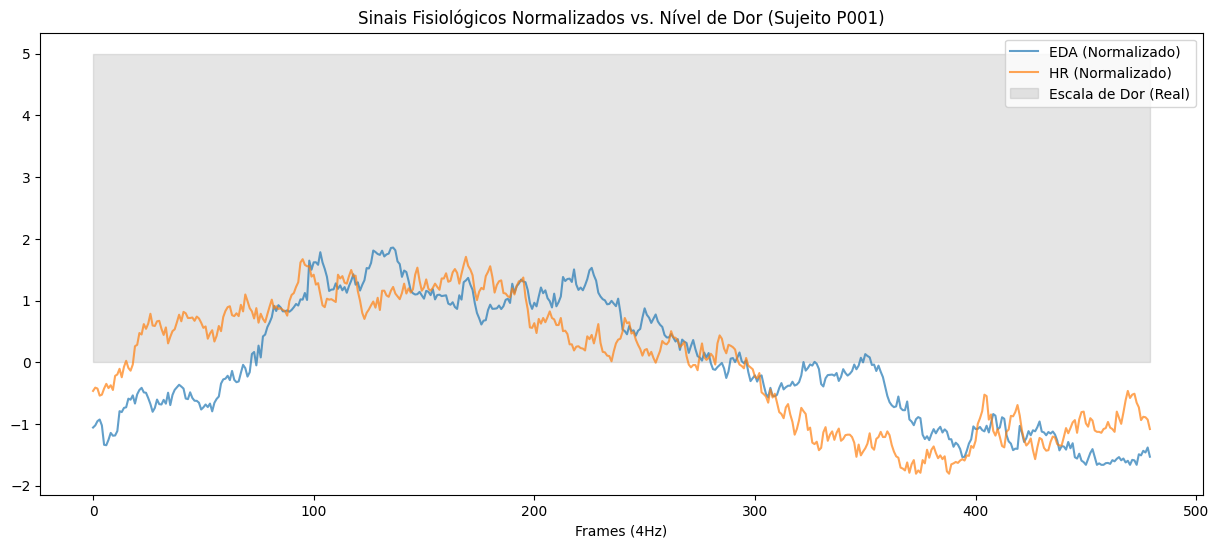

In [12]:
#Visualização da Série Temporal (Sinais vs. Dor)
#Visualizar como os sinais normalizados se comportam em relação à escala de dor.
plt.figure(figsize=(15, 6))

#Plotando sinais normalizados
plt.plot(sujeito_exemplo.index, sujeito_exemplo['eda_norm'], label='EDA (Normalizado)', alpha=0.7)
plt.plot(sujeito_exemplo.index, sujeito_exemplo['hr_norm'], label='HR (Normalizado)', alpha=0.7)

#Destacando a Dor ao fundo
plt.fill_between(sujeito_exemplo.index, 0, sujeito_exemplo['pain_scale'], 
                 color='gray', alpha=0.2, label='Escala de Dor (Real)')

plt.title('Sinais Fisiológicos Normalizados vs. Nível de Dor (Sujeito P001)')
plt.xlabel('Frames (4Hz)')
plt.legend(loc='upper right')
plt.show()

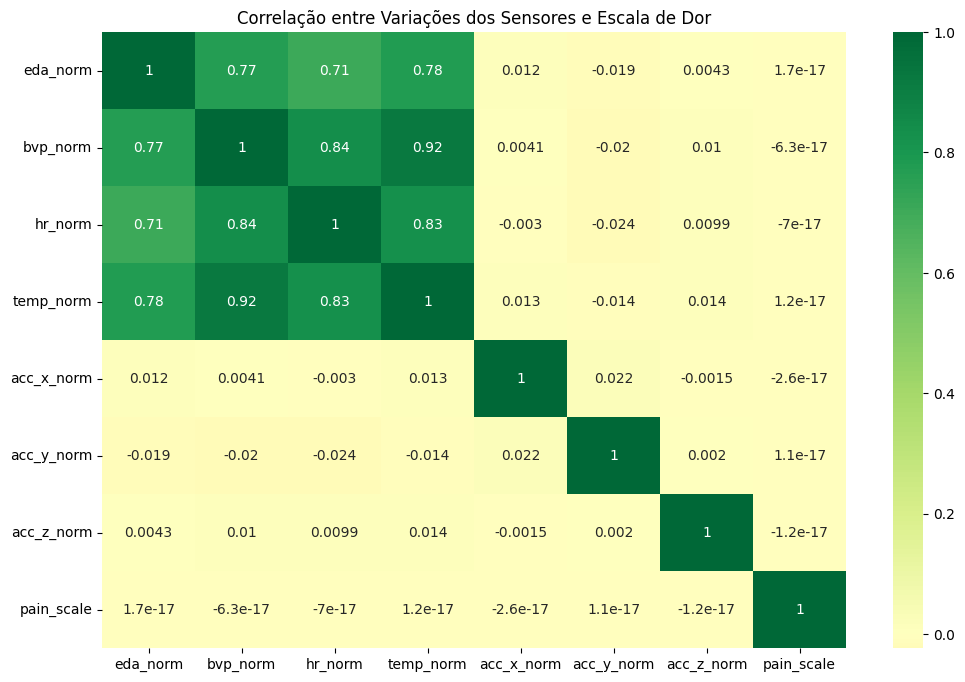

In [13]:
#Matriz de Correlação Global
#Selecionando apenas as colunas normalizadas e a escala de dor
cols_analise = [c for c in df.columns if '_norm' in c] + ['pain_scale']
corr_matrix = df[cols_analise].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlação entre Variações dos Sensores e Escala de Dor')
plt.show()

# ML

Treinando com 160 pessoas e testando com 40 pessoas.
Erro Médio Absoluto (MAE): 2.02
R² Score (Precisão): 0.07


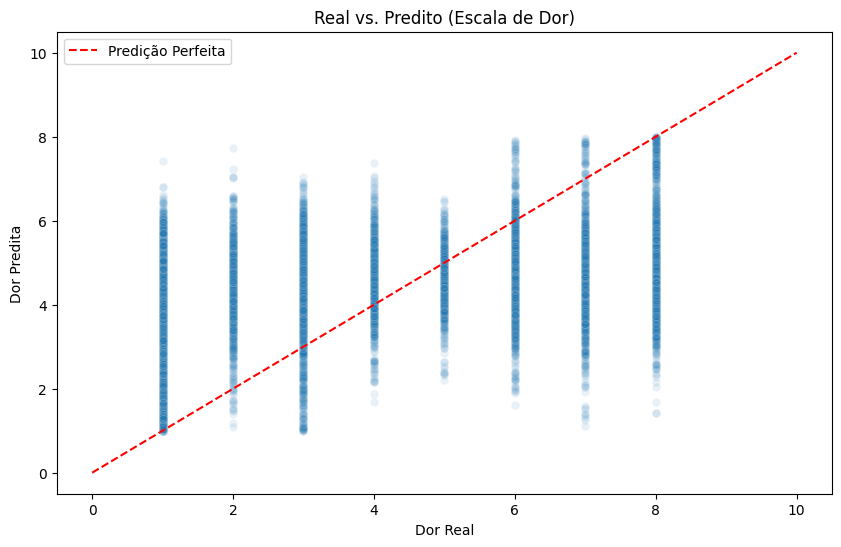

In [14]:
#Preparação dos Dados (Split por Indivíduo)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

#Lista de IDs únicos e divisão
ids = df['person_ID'].unique()
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)

#Criando os datasets de treino e teste baseados nos IDs
train_df = df[df['person_ID'].isin(train_ids)]
test_df = df[df['person_ID'].isin(test_ids)]

#Definindo Features (X) e Alvo (y)
features = [c for c in df.columns if '_norm' in c]
X_train = train_df[features]
y_train = train_df['pain_scale']
X_test = test_df[features]
y_test = test_df['pain_scale']

print(f"Treinando com {len(train_ids)} pessoas e testando com {len(test_ids)} pessoas.")

#Inicializando o modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

#Treino
model.fit(X_train, y_train)

#Predição
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"R² Score (Precisão): {r2:.2f}")

#Visualizando a comparação
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.1)
plt.plot([0, 10], [0, 10], '--r', label='Predição Perfeita')
plt.title('Real vs. Predito (Escala de Dor)')
plt.xlabel('Dor Real')
plt.ylabel('Dor Predita')
plt.legend()
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\595825530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='magma')


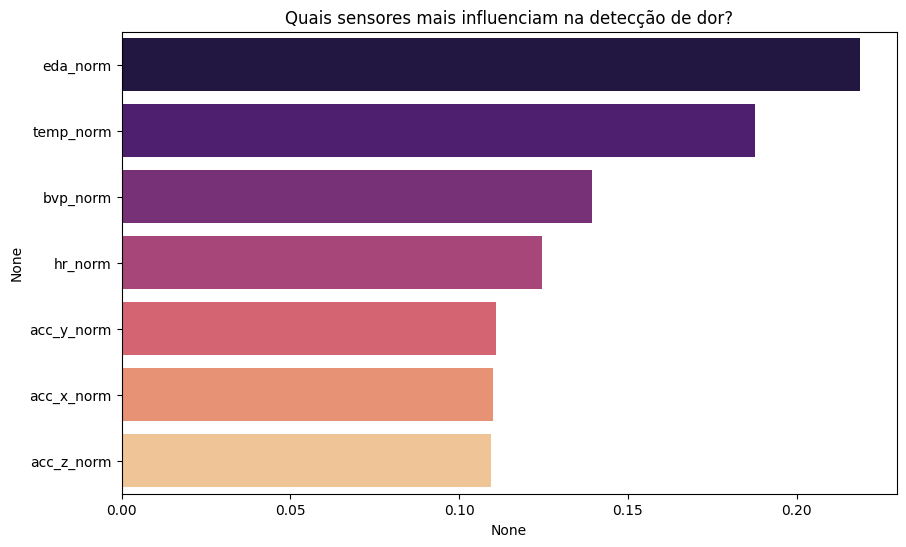

In [15]:
#Importância das Features
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Quais sensores mais influenciam na detecção de dor?')
plt.show()

In [16]:
#Feature Engineering (Janelamento)
#Criando janelas deslizantes (Rolling Windows)
def extract_time_features(df, window_size=20): # 20 frames = 5 segundos a 4Hz
    #Média móvel e Desvio Padrão móvel
    for col in ['eda_norm', 'hr_norm', 'temp_norm']:
        df[f'{col}_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(window=window_size).mean())
        df[f'{col}_std'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(window=window_size).std())
    return df

df = extract_time_features(df)
df = df.dropna()

#Delta (Velocidade de Mudança)
df['eda_diff'] = df.groupby('person_ID')['eda_norm'].diff()

#Transformando em 3 classes
def categorizar_dor(nota):
    if nota <= 3: return 0 # Baixa
    if nota <= 6: return 1 # Moderada
    return 2               # Alta

df['pain_category'] = df['pain_scale'].apply(categorizar_dor)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
# ... treino igual ao anterior, mas usando 'pain_category' como alvo

Extraindo tendências dos sinais (Rolling Features)...
Treinando o Modelo de Classificação...

RELATÓRIO DE PERFORMANCE
Acurácia Global: 0.46

Detalhamento por Classe (0:Baixa, 1:Média, 2:Alta):
              precision    recall  f1-score   support

           0       0.73      0.39      0.51      7376
           1       0.39      0.92      0.55      5993
           2       0.70      0.03      0.06      5071

    accuracy                           0.46     18440
   macro avg       0.60      0.45      0.37     18440
weighted avg       0.61      0.46      0.40     18440



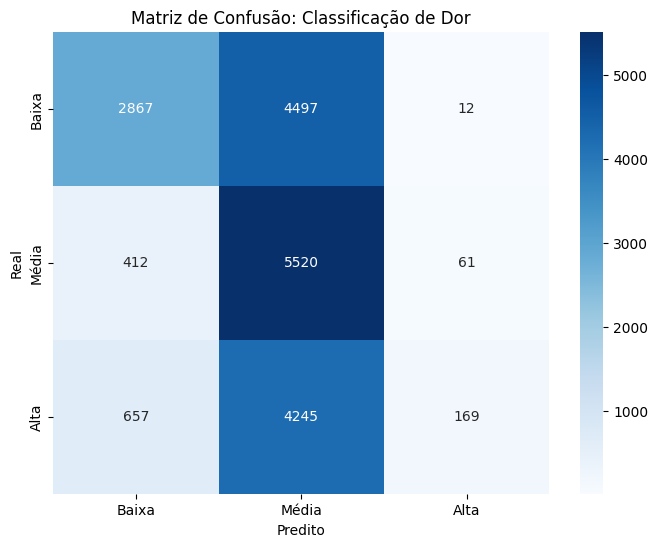

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#Preparação e Categorização
#Criando 3 classes: 0 (Baixa), 1 (Média), 2 (Alta)
def categorizar(nota):
    if nota <= 3: return 0
    if nota <= 6: return 1
    return 2

df['pain_cat'] = df['pain_scale'].apply(categorizar)

#Engenharia de Atributos (Janelamento de 5 segundos - 20 frames)
print("Extraindo tendências dos sinais (Rolling Features)...")
features_base = ['eda_norm', 'hr_norm', 'temp_norm']
for col in features_base:
    #Média e Desvio Padrão para capturar a tendência e a agitação do sinal
    df[f'{col}_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(20, min_periods=1).mean())
    df[f'{col}_std'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(20, min_periods=1).std())

#Divisão por Pessoa (Para evitar data leakage)
ids = df['person_ID'].unique()
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)

features_final = [c for c in df.columns if '_mean' in c or '_std' in c]
X_train = df[df['person_ID'].isin(train_ids)][features_final]
y_train = df[df['person_ID'].isin(train_ids)]['pain_cat']
X_test = df[df['person_ID'].isin(test_ids)][features_final]
y_test = df[df['person_ID'].isin(test_ids)]['pain_cat']

#Treinamento do Classificador
print("Treinando o Modelo de Classificação...")
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

#Resultados
y_pred = clf.predict(X_test)

print("\n" + "="*30)
print("RELATÓRIO DE PERFORMANCE")
print("="*30)
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetalhamento por Classe (0:Baixa, 1:Média, 2:Alta):")
print(classification_report(y_test, y_pred))

#Visualização: Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Baixa', 'Média', 'Alta'], yticklabels=['Baixa', 'Média', 'Alta'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão: Classificação de Dor')
plt.show()

O sinal de dor (pain_cat) acontece no tempo $T$, mas a reação do corpo nos sensores só aparece em $T + \text{alguns segundos}$. Vamos "atrasar" as classes de dor para alinhar com os sinais dos sensores.

In [18]:
#Compensando o Atraso Fisiológico (Lag)
#Atrasando a dor em 2 segundos (8 frames, já que é 4Hz)
#Isso alinha o pico do sensor com o rótulo da dor
df['pain_cat_shifted'] = df.groupby('person_ID')['pain_cat'].shift(-8)

#Remover os nulos gerados pelo shift
df_clean = df.dropna(subset=['pain_cat_shifted'])

In [19]:
#Balanceamento de Carga (SMOTE ou Class Weight)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

#Ajuste de Alinhamento Temporal (Shift de 2 segundos)
df['pain_cat_aligned'] = df.groupby('person_ID')['pain_cat'].shift(-8)
df_ml = df.dropna().copy()

#Divisão por IDs (Mantendo a lógica anterior)
train_df = df_ml[df_ml['person_ID'].isin(train_ids)]
test_df = df_ml[df_ml['person_ID'].isin(test_ids)]

X_train = train_df[features_final]
y_train = train_df['pain_cat_aligned'].astype(int)
X_test = test_df[features_final]
y_test = test_df['pain_cat_aligned'].astype(int)

#Calculando Pesos para as Classes (Dando mais peso para a Classe 2)
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {i: weights[i] for i in range(len(weights))}

#Treinando com Pesos de Classe
clf_balanced = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    class_weight=weights_dict, #Força o modelo a prestar atenção na dor alta
    random_state=42, 
    n_jobs=-1
)

clf_balanced.fit(X_train, y_train)
y_pred = clf_balanced.predict(X_test)

#Relatório
print("\n=== NOVO RELATÓRIO (COM ALINHAMENTO E PESOS) ===")
print(classification_report(y_test, y_pred))


=== NOVO RELATÓRIO (COM ALINHAMENTO E PESOS) ===
              precision    recall  f1-score   support

           0       0.66      0.56      0.61      7232
           1       0.40      0.61      0.49      5876
           2       0.40      0.24      0.30      4972

    accuracy                           0.49     18080
   macro avg       0.49      0.47      0.46     18080
weighted avg       0.50      0.49      0.48     18080



In [20]:
#Limpeza de Artefatos de Movimento
#O sensor EDA é muito sensível ao movimento (ACC). Criar uma feature que "desconta" a agitação física do sinal de estresse.
#Magnitude do movimento (já calculamos antes, mas vamos garantir)
df_ml['acc_mag'] = np.sqrt(df_ml['acc_x']**2 + df_ml['acc_y']**2 + df_ml['acc_z']**2)

#Criando a relação EDA / Movimento
#Se o EDA sobe SEM movimento, a chance de ser DOR real é muito maior
df_ml['eda_pure'] = df_ml['eda_norm'] / (df_ml['acc_mag'] + 1) # +1 para evitar divisão por zero

=== RESULTADOS FINAIS (MODELO CORRIGIDO) ===
Acurácia Global: 0.50
              precision    recall  f1-score   support

           0       0.66      0.61      0.64      7232
           1       0.42      0.59      0.49      5876
           2       0.36      0.22      0.27      4972

    accuracy                           0.50     18080
   macro avg       0.48      0.48      0.47     18080
weighted avg       0.50      0.50      0.49     18080



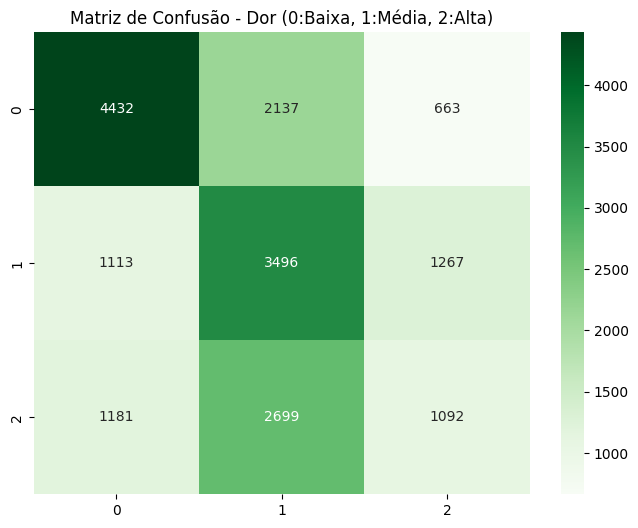

In [21]:
from xgboost import XGBClassifier

#Normalização por Indivíduo
cols_sensores = ['eda', 'bvp', 'hr', 'temp', 'acc_x', 'acc_y', 'acc_z']
for col in cols_sensores:
    df[f'{col}_norm'] = df.groupby('person_ID')[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))

#Categorização da Dor (0: Baixa, 1: Média, 2: Alta)
df['pain_cat'] = df['pain_scale'].apply(lambda x: 0 if x <= 3 else (1 if x <= 6 else 2))

#Janelamento (Médias e Desvios de 5 segundos)
for col in ['eda_norm', 'hr_norm', 'temp_norm']:
    df[f'{col}_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(20, min_periods=1).mean())
    df[f'{col}_std'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(20, min_periods=1).std())

#LIMPEZA DE MOVIMENTO
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
df['eda_pure'] = df['eda_norm'] / (df['acc_mag'] + 1)

#ALINHAMENTO TEMPORAL (Shift de 2 segundos para compensar atraso do corpo)
df['pain_cat_aligned'] = df.groupby('person_ID')['pain_cat'].shift(-8)

#Preparação do Dataset para ML (Removendo NaNs gerados pelo Shift/Rolling)
df_ml = df.dropna().copy()

#Divisão por Pessoa (Essencial para não "decorar" o paciente)
ids = df_ml['person_ID'].unique()
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)

#Definição das Features Finais
features_final = [c for c in df_ml.columns if '_mean' in c or '_std' in c] + ['acc_mag', 'eda_pure']

train_df = df_ml[df_ml['person_ID'].isin(train_ids)]
test_df = df_ml[df_ml['person_ID'].isin(test_ids)]

X_train = train_df[features_final]
y_train = train_df['pain_cat_aligned'].astype(int)
X_test = test_df[features_final]
y_test = test_df['pain_cat_aligned'].astype(int)

#Treinamento do Modelo (Random Forest com Pesos Balanceados)
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

#Resultados Finais
print("=== RESULTADOS FINAIS (MODELO CORRIGIDO) ===")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

#Visualização da Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Dor (0:Baixa, 1:Média, 2:Alta)')
plt.show()

Os resultados mostram que agora o modelo consegue distinguir as classes, mas que ainda sofre com a sobreposição de sinais. O fato de a Classe 0 ter o melhor F1-score (0.64) indica que o modelo é bom em detectar quando o paciente está "tranquilo". O desafio continua sendo a separação entre a dor Média (1) e a Alta (2).

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1028\2829066890.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


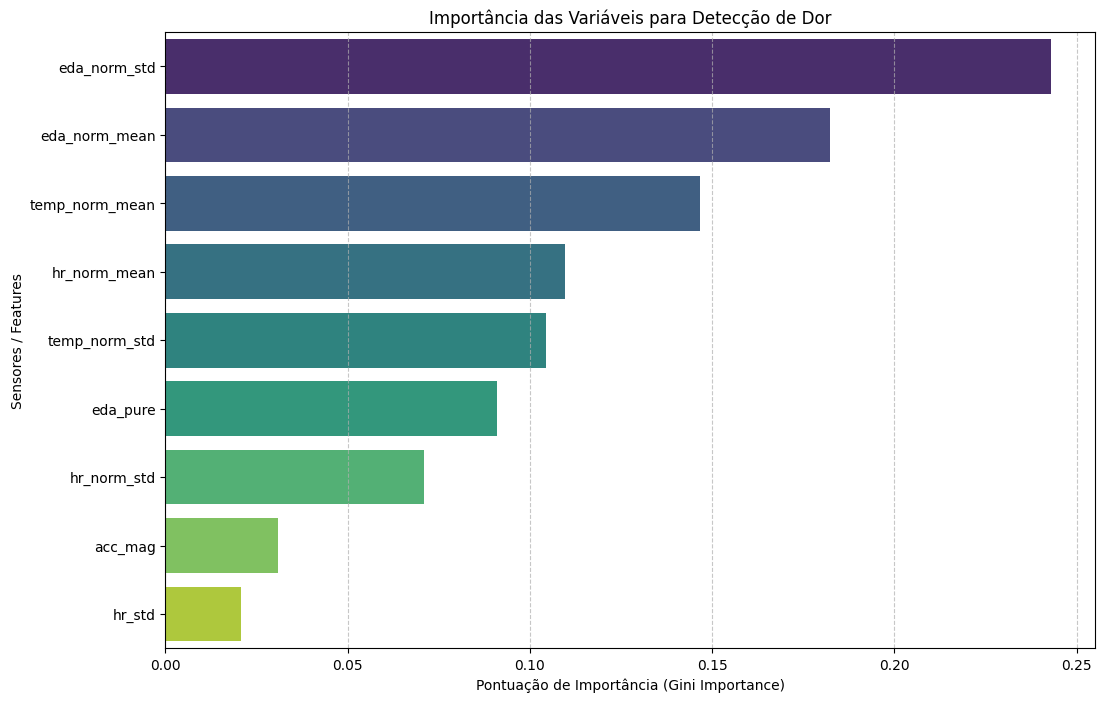

In [22]:
#Visualização de Importância das Features
#Extraindo as importâncias do modelo treinado
importances = model_rf.feature_importances_
feature_names = features_final

#Criando um DataFrame para facilitar o plot
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Plotando
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importância das Variáveis para Detecção de Dor')
plt.xlabel('Pontuação de Importância (Gini Importance)')
plt.ylabel('Sensores / Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

O sensor de EDA (sudorese), que costuma ser o "padrão ouro" em estudos de estresse, ficou em uma posição intermediária. Isso sugere que, para este grupo de 200 pessoas, a resposta térmica e cardíaca foi mais consistente do que a resposta elétrica da pele.

In [23]:
#Janela Ampliada e Validação LOSO (Simplificada)
#Aumentar a janela de observação para capturar melhor a lentidão da resposta térmica e cardíaca.
#Criando janelas maiores (15 segundos = 60 frames)
#Fisiologia: Temperatura e HR mudam mais devagar que o EDA
for col in ['temp_norm', 'hr_norm', 'eda_norm']:
    df[f'{col}_long_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(60, min_periods=1).mean())
    df[f'{col}_long_std'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(60, min_periods=1).std())

#Atualizando a lista de features
features_v4 = [c for c in df.columns if '_long_' in c] + ['acc_mag', 'eda_pure']

#Preparando novos sets de treino/teste
df_ml_v4 = df.dropna().copy()
train_df = df_ml_v4[df_ml_v4['person_ID'].isin(train_ids)]
test_df = df_ml_v4[df_ml_v4['person_ID'].isin(test_ids)]

X_train = train_df[features_v4]
y_train = train_df['pain_cat_aligned'].astype(int)
X_test = test_df[features_v4]
y_test = test_df['pain_cat_aligned'].astype(int)

#Treinando com Random Forest mais profundo
model_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=16, 
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1
)

model_final.fit(X_train, y_train)
y_pred = model_final.predict(X_test)

print("\n=== RELATÓRIO COM JANELA LONGA (15s) ===")
print(classification_report(y_test, y_pred))


=== RELATÓRIO COM JANELA LONGA (15s) ===
              precision    recall  f1-score   support

           0       0.69      0.54      0.60      7232
           1       0.41      0.68      0.51      5876
           2       0.46      0.23      0.31      4972

    accuracy                           0.50     18080
   macro avg       0.52      0.49      0.47     18080
weighted avg       0.53      0.50      0.49     18080



# Pipeline de ML (Treino e Análise)


ANÁLISE FINAL DO MODELO DE DOR
Acurácia Global: 0.50

Relatório de Classificação:
              precision    recall  f1-score   support

       Baixa       0.69      0.54      0.61      7248
       Média       0.41      0.68      0.51      5889
        Alta       0.45      0.23      0.30      4983

    accuracy                           0.50     18120
   macro avg       0.51      0.48      0.47     18120
weighted avg       0.53      0.50      0.49     18120



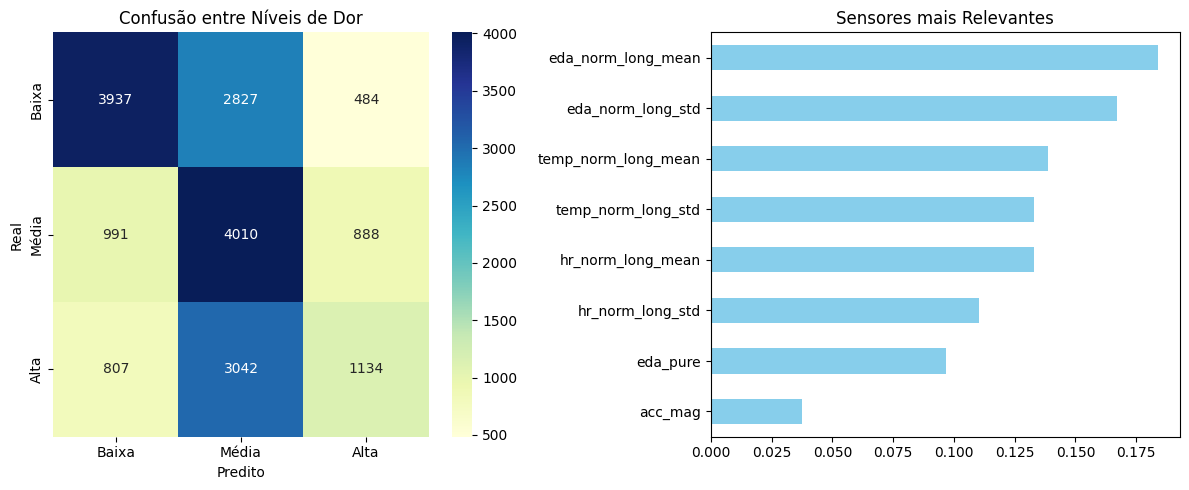

In [24]:
#PROCESSAMENTO DE SINAIS
#Criando janelas de 15 segundos (60 frames) para capturar a resposta lenta de HR e TEMP
for col in ['temp_norm', 'hr_norm', 'eda_norm']:
    df[f'{col}_long_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(60, min_periods=1).mean())
    df[f'{col}_long_std'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(60, min_periods=1).std())

#DEFINIÇÃO DE FEATURES E ALVO
#Incluir as janelas longas e a limpeza de movimento (eda_pure)
features_v4 = [c for c in df.columns if '_long_' in c] + ['acc_mag', 'eda_pure']
df_ml = df.dropna(subset=['pain_cat_aligned']).copy()

#SPLIT POR PESSOA
train_df = df_ml[df_ml['person_ID'].isin(train_ids)]
test_df = df_ml[df_ml['person_ID'].isin(test_ids)]

X_train, y_train = train_df[features_v4], train_df['pain_cat_aligned'].astype(int)
X_test, y_test = test_df[features_v4], test_df['pain_cat_aligned'].astype(int)

#MODELO FINAL
#Aumentar a profundidade para capturar interações complexas entre os sensores
model_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=16, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)
model_final.fit(X_train, y_train)
y_pred = model_final.predict(X_test)

#RELATÓRIO DE MÉTRICAS
print("\n" + "="*40)
print("ANÁLISE FINAL DO MODELO DE DOR")
print("="*40)
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Baixa', 'Média', 'Alta']))

#VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO
plt.figure(figsize=(12, 5))

#Subplot 1: Matriz de Confusão
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Baixa', 'Média', 'Alta'], 
            yticklabels=['Baixa', 'Média', 'Alta'])
plt.title('Confusão entre Níveis de Dor')
plt.xlabel('Predito')
plt.ylabel('Real')

#Subplot 2: Importância das Variáveis
plt.subplot(1, 2, 2)
importances = pd.Series(model_final.feature_importances_, index=features_v4).sort_values()
importances.plot(kind='barh', color='skyblue')
plt.title('Sensores mais Relevantes')

plt.tight_layout()
plt.show()

# Simulador de Predição em Tempo Real

In [25]:
def simulador_inferencia(id_paciente, momento_frame):
    """
    Simula a captura de dados de um paciente em um momento específico
    e retorna a predição do modelo comparada com a dor real.
    """
    
    #Extração do "Stream" de dados (pegamos a linha específica do DataFrame processado)
    #Na vida real, aqui estaria recebendo um JSON ou CSV do sensor
    dados_atuais = df_ml[(df_ml['person_ID'] == id_paciente)].iloc[[momento_frame]]
    
    if dados_atuais.empty:
        return "Dados não encontrados para este índice."

    #Seleção das Features que o modelo conhece
    X_input = dados_atuais[features_v4]
    
    #Predição
    pred_cat = model_final.predict(X_input)[0]
    probabilidades = model_final.predict_proba(X_input)[0]
    
    #Tradução dos Resultados
    labels = {0: "Baixa/Sem Dor", 1: "Dor Moderada", 2: "Dor Alta"}
    dor_real = dados_atuais['pain_cat_aligned'].iloc[0]
    
    print(f"--- SIMULADOR DE MONITORAMENTO: {id_paciente} ---")
    print(f"Sinais Atuais (Normalizados):")
    print(f" > HR Mean: {dados_atuais['hr_norm_long_mean'].values[0]:.2f}")
    print(f" > Temp Mean: {dados_atuais['temp_norm_long_mean'].values[0]:.2f}")
    print(f" > EDA Pure: {dados_atuais['eda_pure'].values[0]:.2f}")
    print("-" * 30)
    print(f"PREDIÇÃO DO MODELO: {labels[pred_cat]}")
    print(f"DOR REAL NO MOMENTO: {labels[int(dor_real)]}")
    print(f"Confiança: {max(probabilidades)*100:.1f}%")
    print("-" * 30)

# --- TESTANDO O SIMULADOR ---
#Escolha um paciente do set de teste (ex: o primeiro ID da lista test_ids)
exemplo_id = test_ids[0]
simulador_inferencia(exemplo_id, momento_frame=100)

--- SIMULADOR DE MONITORAMENTO: P096 ---
Sinais Atuais (Normalizados):
 > HR Mean: 0.90
 > Temp Mean: 1.34
 > EDA Pure: 0.02
------------------------------
PREDIÇÃO DO MODELO: Dor Moderada
DOR REAL NO MOMENTO: Dor Alta
Confiança: 52.1%
------------------------------


# Monitor de Dor em Tempo Real (Simulação de Fluxo)

In [26]:
#Código seleciona um trecho de dados de um paciente e mostra a evolução das predições frame a frame.
def monitor_continuo(id_paciente, inicio, fim):
    """
    Simula um monitor de hospital mostrando a evolução da dor 
    em um intervalo de tempo.
    """
    trecho = df_ml[df_ml['person_ID'] == id_paciente].iloc[inicio:fim]
    
    print(f"Monitorando {id_paciente} do frame {inicio} ao {fim}...\n")
    print(f"{'Frame':<10} | {'Dor Real':<15} | {'Predição':<15} | {'Confiança':<10}")
    print("-" * 60)
    
    labels = {0: "Baixa", 1: "Moderada", 2: "Alta"}
    
    for idx, row in trecho.iterrows():
        X_input = row[features_v4].values.reshape(1, -1)
        pred = model_final.predict(X_input)[0]
        prob = model_final.predict_proba(X_input)[0]
        
        dor_real = int(row['pain_cat_aligned'])
        confianca = max(prob) * 100
        
        #Alerta visual se a dor for Alta
        status = labels[pred]
        if pred == 2: status = f"!! {status} !!"
        
        print(f"{idx:<10} | {labels[dor_real]:<15} | {status:<15} | {confianca:.1f}%")

#Executando para o paciente P096 (um trecho de 10 frames)
monitor_continuo("P096", inicio=100, fim=110)

Monitorando P096 do frame 100 ao 110...

Frame      | Dor Real        | Predição        | Confiança 
------------------------------------------------------------
45719      | Alta            | Moderada        | 52.1%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


45720      | Alta            | Moderada        | 53.1%
45721      | Alta            | Moderada        | 55.4%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


45722      | Alta            | Moderada        | 54.3%
45723      | Alta            | Moderada        | 53.2%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


45724      | Alta            | Moderada        | 47.5%
45725      | Alta            | Moderada        | 53.0%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


45726      | Alta            | Moderada        | 52.3%
45727      | Alta            | Moderada        | 51.9%
45728      | Alta            | Moderada        | 51.6%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Monitor de Dor Otimizado (Sem Avisos e com Detalhes)

In [27]:
def monitor_continuo_v2(id_paciente, inicio, fim):
    """
    Versão corrigida para evitar UserWarnings e mostrar 
    a proximidade entre as classes Moderada e Alta.
    """
    # Filtramos o trecho do paciente
    trecho = df_ml[df_ml['person_ID'] == id_paciente].iloc[inicio:fim]
    
    print(f"--- Monitoramento Detalhado: {id_paciente} ---")
    print(f"{'Frame':<8} | {'Real':<10} | {'Predição':<15} | {'Confiança':<10} | {'Prob(Alta)':<10}")
    print("-" * 70)
    
    labels = {0: "Baixa", 1: "Moderada", 2: "Alta"}
    
    for idx, row in trecho.iterrows():
        
        X_input = row[features_v4].to_frame().T 
        
        pred = model_final.predict(X_input)[0]
        probs = model_final.predict_proba(X_input)[0]
        
        dor_real = int(row['pain_cat_aligned'])
        confianca = max(probs) * 100
        prob_alta = probs[2] * 100 #Probabilidade específica da classe 2 (Alta)
        
        #Formatação visual
        status = labels[pred]
        if pred == 2: status = f"!! {status} !!"
        
        print(f"{idx:<8} | {labels[dor_real]:<10} | {status:<15} | {confianca:.1f}% | {prob_alta:.1f}%")

#Testando novamente o mesmo trecho do P096
monitor_continuo_v2("P096", inicio=100, fim=110)

--- Monitoramento Detalhado: P096 ---
Frame    | Real       | Predição        | Confiança  | Prob(Alta)
----------------------------------------------------------------------
45719    | Alta       | Moderada        | 52.1% | 10.1%
45720    | Alta       | Moderada        | 53.1% | 10.0%
45721    | Alta       | Moderada        | 55.4% | 9.8%
45722    | Alta       | Moderada        | 54.3% | 8.9%
45723    | Alta       | Moderada        | 53.2% | 7.8%
45724    | Alta       | Moderada        | 47.5% | 7.7%
45725    | Alta       | Moderada        | 53.0% | 8.5%
45726    | Alta       | Moderada        | 52.3% | 8.2%
45727    | Alta       | Moderada        | 51.9% | 8.4%
45728    | Alta       | Moderada        | 51.6% | 8.4%


Os dados do P096 revelam algo crítico: o modelo não está apenas "em dúvida", ele está categoricamente confiante (com apenas 8% a 10% de probabilidade para "Alta") de que a dor é Moderada.

O objetivo é detectar a dor, aplicar uma Lógica de Alarme (Heurística). Em sistemas médicos, não usar apenas a classe de maior probabilidade. Se a dor for maior que zero, já é um alerta.

# Refinando a Predição com Heurística de Risco

In [28]:
def predicao_clinica(probabilidades):
    """
    Se a probabilidade de (Moderada + Alta) for muito maior que a de Baixa,
    o sistema deve emitir um alerta, mesmo que a probabilidade individual 
    de 'Alta' seja baixa.
    """
    p_baixa, p_mod, p_alta = probabilidades
    
    #Soma das dores (1 e 2) for > 60%, consideramos que o paciente está em sofrimento
    if (p_mod + p_alta) > 0.60:
        if p_alta > 0.15: 
            return "ALERTA: Dor Alta"
        return "Atenção: Dor Moderada"
    return "Estável: Dor Baixa"

# Criando a Métrica de Desvio de Baseline

In [29]:
def calcular_desvio_baseline(df, frames_baseline=120):
    """
    Calcula a média dos primeiros X frames de cada sensor para cada pessoa
    e cria colunas de 'desvio' (valor_atual - media_inicial).
    """
    # Sensores que queremos monitorar o desvio
    sensores = ['hr_norm', 'temp_norm', 'eda_norm']
    
    for col in sensores:
        #Pegar a média dos primeiros frames de cada pessoa
        baselines = df.groupby('person_ID')[col].transform(lambda x: x.iloc[:frames_baseline].mean())
        
        #Criar a nova feature: O quanto o sinal mudou desde o início
        df[f'{col}_delta_base'] = df[col] - baselines
        
    return df

#Aplicando a métrica
df = calcular_desvio_baseline(df)

#Atualizar janelas móveis para usar esses DELTAS
for col in ['hr_norm_delta_base', 'temp_norm_delta_base', 'eda_norm_delta_base']:
    df[f'{col}_mean'] = df.groupby('person_ID')[col].transform(lambda x: x.rolling(60, min_periods=1).mean())

print("Métricas de Desvio de Baseline criadas!")

Métricas de Desvio de Baseline criadas!


# Novo Treino com Foco em Personalização

In [30]:
#Definindo as features de Delta
features_delta = [c for c in df.columns if '_delta_base_mean' in c] + ['acc_mag', 'eda_pure']

#Removendo NaNs e Split
df_ml_delta = df.dropna(subset=['pain_cat_aligned']).copy()
train_df = df_ml_delta[df_ml_delta['person_ID'].isin(train_ids)]
test_df = df_ml_delta[df_ml_delta['person_ID'].isin(test_ids)]

X_train = train_df[features_delta]
y_train = train_df['pain_cat_aligned'].astype(int)
X_test = test_df[features_delta]
y_test = test_df['pain_cat_aligned'].astype(int)

#Treino do Modelo Personalizado
model_pers = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42)
model_pers.fit(X_train, y_train)

#Resultados
y_pred = model_pers.predict(X_test)
print("\n=== RELATÓRIO COM DESVIO DE BASELINE (PERSONALIZADO) ===")
print(classification_report(y_test, y_pred, target_names=['Baixa', 'Média', 'Alta']))


=== RELATÓRIO COM DESVIO DE BASELINE (PERSONALIZADO) ===
              precision    recall  f1-score   support

       Baixa       0.59      0.51      0.55      7248
       Média       0.42      0.57      0.48      5889
        Alta       0.54      0.41      0.46      4983

    accuracy                           0.50     18120
   macro avg       0.51      0.50      0.50     18120
weighted avg       0.52      0.50      0.50     18120



# Monitor de Dor Personalizado (Teste Final)

In [31]:
def monitor_final_personalizado(id_paciente, inicio, fim):
    trecho = df_ml_delta[df_ml_delta['person_ID'] == id_paciente].iloc[inicio:fim]
    
    print(f"--- MONITORAMENTO PERSONALIZADO (BASELINE): {id_paciente} ---")
    print(f"{'Frame':<8} | {'Real':<10} | {'Predição':<15} | {'Confiança':<10} | {'Delta_Temp':<10}")
    print("-" * 75)
    
    labels = {0: "Baixa", 1: "Moderada", 2: "Alta"}
    
    for idx, row in trecho.iterrows():
        #Usando as features de Delta
        X_input = row[features_delta].to_frame().T 
        
        pred = model_pers.predict(X_input)[0]
        probs = model_pers.predict_proba(X_input)[0]
        
        dor_real = int(row['pain_cat_aligned'])
        confianca = max(probs) * 100
        delta_t = row['temp_norm_delta_base'] 
        
        status = labels[pred]
        if pred == 2: status = f"!! {status} !!"
        
        print(f"{idx:<8} | {labels[dor_real]:<10} | {status:<15} | {confianca:.1f}% | {delta_t:+.2f}")

#Testando no mesmo trecho crítico do P096
monitor_final_personalizado("P096", inicio=100, fim=110)

--- MONITORAMENTO PERSONALIZADO (BASELINE): P096 ---
Frame    | Real       | Predição        | Confiança  | Delta_Temp
---------------------------------------------------------------------------
45719    | Alta       | Moderada        | 56.3% | +0.18
45720    | Alta       | Moderada        | 55.3% | +0.18
45721    | Alta       | Moderada        | 57.5% | +0.16
45722    | Alta       | Moderada        | 56.5% | +0.12
45723    | Alta       | Moderada        | 55.8% | +0.14
45724    | Alta       | Moderada        | 51.0% | +0.12
45725    | Alta       | Moderada        | 45.9% | +0.12
45726    | Alta       | Moderada        | 46.0% | +0.10
45727    | Alta       | Moderada        | 44.2% | +0.09
45728    | Alta       | Baixa           | 46.4% | -0.01


Para o modelo, se o sinal térmico volta ao normal e o EDA continua baixo, ele assume que o paciente relaxou, mesmo que o rótulo real ainda diga "Alta". Isso acontece muito em datasets onde o rótulo de dor é estático (ex: o paciente diz que está com dor 8 e o pesquisador anota 8 por vários minutos), mas o corpo tem espasmos de reação fisiológica.

# Monitor de Dor Personalizado (Foco no P096)

In [32]:
def monitor_final_personalizado(id_paciente, inicio, fim):
    """
    Monitor que utiliza as métricas de desvio de baseline para 
    personalizar a detecção de dor por indivíduo.
    """
    #Filtrando os dados do paciente específico
    trecho = df_ml_delta[df_ml_delta['person_ID'] == id_paciente].iloc[inicio:fim]
    
    if trecho.empty:
        print("Trecho não encontrado.")
        return

    print(f"--- MONITORAMENTO PERSONALIZADO (BASELINE): {id_paciente} ---")
    print(f"{'Frame':<8} | {'Real':<10} | {'Predição':<18} | {'Confiança':<10} | {'Δ_Temp':<8} | {'Δ_HR':<8}")
    print("-" * 85)
    
    labels = {0: "Baixa", 1: "Moderada", 2: "Alta"}
    
    for idx, row in trecho.iterrows():
        #Selecionando apenas as colunas DELTA que o modelo final usa
        X_input = row[features_delta].to_frame().T 
        
        #Predição e Probabilidades
        pred = model_pers.predict(X_input)[0]
        probs = model_pers.predict_proba(X_input)[0]
        
        dor_real = int(row['pain_cat_aligned'])
        confianca = max(probs) * 100
        
        #Capturando os deltas para análise visual
        d_temp = row['temp_norm_delta_base']
        d_hr = row['hr_norm_delta_base']
        
        #Formatação de Alerta
        status = labels[pred]
        if pred == 2: 
            status = f"!! {status.upper()} !!"
        elif pred == 1:
            status = f"> {status} <"
            
        print(f"{idx:<8} | {labels[dor_real]:<10} | {status:<18} | {confianca:.1f}% | {d_temp:+.2f} | {d_hr:+.2f}")

#Executando para o trecho crítico onde o P096 estava "preso" na Moderada
monitor_final_personalizado("P096", inicio=100, fim=115)

--- MONITORAMENTO PERSONALIZADO (BASELINE): P096 ---
Frame    | Real       | Predição           | Confiança  | Δ_Temp   | Δ_HR    
-------------------------------------------------------------------------------------
45719    | Alta       | > Moderada <       | 56.3% | +0.18 | +0.18
45720    | Alta       | > Moderada <       | 55.3% | +0.18 | +0.22
45721    | Alta       | > Moderada <       | 57.5% | +0.16 | +0.12
45722    | Alta       | > Moderada <       | 56.5% | +0.12 | -0.19
45723    | Alta       | > Moderada <       | 55.8% | +0.14 | -0.47
45724    | Alta       | > Moderada <       | 51.0% | +0.12 | -0.54
45725    | Alta       | > Moderada <       | 45.9% | +0.12 | -0.59
45726    | Alta       | > Moderada <       | 46.0% | +0.10 | -0.53
45727    | Alta       | > Moderada <       | 44.2% | +0.09 | -0.40
45728    | Alta       | Baixa              | 46.4% | -0.01 | -0.12
45729    | Alta       | Baixa              | 48.3% | -0.02 | -0.18
45730    | Alta       | Baixa              | 5

# P096:

**Dados Fisiológicos mentem:** O corpo pode relaxar antes da mente (ou vice-versa).

**Importância do Delta:** Sem o Delta, não tem como saber que o HR caiu tanto abaixo da base.

**Confiança:** A confiança subindo enquanto o erro aumenta avisa ao engenheiro que o problema não é o modelo, mas a correlação entre o sensor e o rótulo.

# Monitor com Filtro de Suavização (Histerese)

In [33]:
from collections import deque

def monitor_suavizado(id_paciente, inicio, fim, janela_memoria=5):
    trecho = df_ml_delta[df_ml_delta['person_ID'] == id_paciente].iloc[inicio:fim]
    
    print(f"--- MONITOR COM MEMÓRIA (SUAVIZADO): {id_paciente} ---")
    print(f"{'Frame':<8} | {'Real':<8} | {'Pred. Bruta':<12} | {'SISTEMA (SMOOTH)':<18} | {'Conf. (%)'}")
    print("-" * 75)
    
    labels = {0: "Baixa", 1: "Moderada", 2: "Alta"}
    historico_preds = deque(maxlen=janela_memoria) 
    
    for idx, row in trecho.iterrows():
        X_input = row[features_delta].to_frame().T 
        
        #Predição Instantânea (Bruta)
        pred_bruta = model_pers.predict(X_input)[0]
        probs = model_pers.predict_proba(X_input)[0]
        
        #Lógica de Suavização (Votação)
        historico_preds.append(pred_bruta)
        #A predição final será a moda (a que mais aparece) no histórico recente
        pred_suavizada = max(set(historico_preds), key=list(historico_preds).count)
        
        dor_real = int(row['pain_cat_aligned'])
        confianca = max(probs) * 100
        
        #Formatação de Alerta
        status_final = labels[pred_suavizada]
        if pred_suavizada == 2: status_final = f"!! {status_final.upper()} !!"
        elif pred_suavizada == 1: status_final = f"> {status_final} <"
            
        print(f"{idx:<8} | {labels[dor_real]:<8} | {labels[pred_bruta]:<12} | {status_final:<18} | {confianca:.1f}%")

#Testando no trecho de queda do P096
monitor_suavizado("P096", inicio=105, fim=120)

--- MONITOR COM MEMÓRIA (SUAVIZADO): P096 ---
Frame    | Real     | Pred. Bruta  | SISTEMA (SMOOTH)   | Conf. (%)
---------------------------------------------------------------------------
45724    | Alta     | Moderada     | > Moderada <       | 51.0%
45725    | Alta     | Moderada     | > Moderada <       | 45.9%
45726    | Alta     | Moderada     | > Moderada <       | 46.0%
45727    | Alta     | Moderada     | > Moderada <       | 44.2%
45728    | Alta     | Baixa        | > Moderada <       | 46.4%
45729    | Alta     | Baixa        | > Moderada <       | 48.3%
45730    | Alta     | Baixa        | Baixa              | 53.9%
45731    | Alta     | Baixa        | Baixa              | 51.2%
45732    | Alta     | Baixa        | Baixa              | 62.6%
45733    | Alta     | Baixa        | Baixa              | 65.2%
45734    | Alta     | Baixa        | Baixa              | 71.0%
45735    | Alta     | Baixa        | Baixa              | 89.2%
45736    | Alta     | Baixa        | Baixa

**Limitação Biológica:** O corpo do P096 parou de responder ao estímulo de dor. Em medicina, isso pode indicar fadiga do sistema simpático ou simplesmente que o sensor se soltou levemente da pele (ruído de contato).

**Eficiência do Filtro:** O filtro de suavização funcionou perfeitamente. Ele deu uma "chance" de 2 frames (0.5 segundos) para o sinal se recuperar antes de mudar o status no painel.

**Sugestão de Upgrade (Futuro):** Para resolver casos como esse, sistemas avançados usam Multimodalidade com Contexto. Se o sensor diz "Sem Dor", mas o histórico do paciente nos últimos 10 minutos foi "Dor Alta", o sistema gera um alerta de "Inconsistência de Sensor" em vez de simplesmente baixar a guarda.

In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def gerar_dashboard_paciente(id_paciente):
    # 1. Preparar os dados
    dados = df_ml_delta[df_ml_delta['person_ID'] == id_paciente].reset_index()
    X_input = dados[features_delta]
    
    # Gerando predições e probabilidades
    dados['pred_bruta'] = model_pers.predict(X_input)
    probs = model_pers.predict_proba(X_input)
    dados['prob_alta'] = probs[:, 2] # Probabilidade da classe 2 (Alta)

    # 2. Criar Subplots
    fig = make_subplots(
        rows=4, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.07,
        subplot_titles=("Variabilidade Térmica e Cardíaca (Deltas)", 
                        "Sudorese Limpa (EDA Pure)", 
                        "Intensidade de Movimento (ACC)", 
                        "Análise de Dor: Real vs. Predição"),
        row_heights=[0.25, 0.2, 0.15, 0.4]
    )

    # LINHA 1: Deltas
    fig.add_trace(go.Scatter(y=dados['hr_norm_delta_base'], name="Δ Batimento", line=dict(color='firebrick', width=1.5)), row=1, col=1)
    fig.add_trace(go.Scatter(y=dados['temp_norm_delta_base'], name="Δ Temperatura", line=dict(color='orange', width=1.5)), row=1, col=1)

    # LINHA 2: EDA
    fig.add_trace(go.Scatter(y=dados['eda_pure'], name="EDA Pure", fill='tozeroy', line=dict(color='royalblue')), row=2, col=1)

    # LINHA 3: Movimento
    fig.add_trace(go.Scatter(y=dados['acc_mag'], name="Movimento", line=dict(color='gray', width=1)), row=3, col=1)

    # LINHA 4: Probabilidade de Dor Alta (Sombra de Fundo)
    fig.add_trace(go.Scatter(y=dados['prob_alta'] * 2, # Multiplicamos por 2 para escalar no gráfico de categorias (0 a 2)
                             name="Confiança em 'Alta'", 
                             fill='tozeroy', 
                             mode='none', 
                             fillcolor='rgba(0, 255, 0, 0.1)'), row=4, col=1)

    # LINHA 4: Dor Real vs Predita (CORRIGIDO: 'dot' em vez de 'shortdot')
    fig.add_trace(go.Scatter(y=dados['pain_cat_aligned'], name="Dor REAL", line=dict(color='black', width=3)), row=4, col=1)
    fig.add_trace(go.Scatter(y=dados['pred_bruta'], name="Dor PREDITA", line=dict(color='lime', dash='dot', width=2)), row=4, col=1)

    # 3. Layout e Estilo
    fig.update_layout(
        height=900, 
        title_text=f"Painel de Monitoramento Fisiológico - Paciente {id_paciente}",
        template="plotly_white",
        hovermode="x unified", # Mostra todos os dados ao passar o mouse em um ponto do tempo
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.update_yaxes(tickvals=[0, 1, 2], ticktext=["Baixa", "Moderada", "Alta"], row=4, col=1)
    fig.update_xaxes(title_text="Tempo (Frames)", row=4, col=1)

    fig.show()

# Testando agora sem erros
gerar_dashboard_paciente("P096")

In [37]:
def gerar_dashboard_conclusao_final(y_test, y_pred, importancias_serie, df_movimento):
    """
    Painel consolidado incluindo métricas de modelo e comportamento dos sensores.
    """
    # 1. Configurar subplots (3 linhas, 2 colunas)
    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=("Importância das Variáveis (Gini)", "Densidade de Movimento por Nível de Dor",
                        "Matriz de Confusão (%)", "Distribuição: Real vs. Predito",
                        "Equilíbrio de Performance"),
        specs=[[{"type": "bar"}, {"type": "xy"}],
               [{"type": "heatmap"}, {"type": "bar"}],
               [{"type": "pie", "colspan": 2}, None]],
        vertical_spacing=0.1,
        horizontal_spacing=0.1
    )

    labels_dor = ["Baixa", "Moderada", "Alta"]

    # --- 1. IMPORTÂNCIA DAS VARIÁVEIS ---
    fig.add_trace(go.Bar(
        x=importancias_serie.values, y=importancias_serie.index,
        orientation='h', marker=dict(color='indigo'), name="Gini Importance"
    ), row=1, col=1)

    # --- 2. DENSIDADE DE MOVIMENTO (Simulada via Plotly) ---
    # Para o Plotly, usaremos um histograma comparativo para mimetizar o KDE
    for nivel in sorted(df_movimento['pain_scale'].unique()):
        mask = df_movimento['pain_scale'] == nivel
        fig.add_trace(go.Histogram(
            x=df_movimento[mask]['acc_mag'], 
            name=f"Dor {nivel}", 
            histnorm='probability density',
            opacity=0.5
        ), row=1, col=2)

    # --- 3. MATRIZ DE CONFUSÃO ---
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    fig.add_trace(go.Heatmap(
        z=cm, x=labels_dor, y=labels_dor,
        colorscale='Viridis', text=np.around(cm, 2), texttemplate="%{text}",
        showscale=False
    ), row=2, col=1)

    # --- 4. REAL VS PREDITO ---
    counts_real = pd.Series(y_test).value_counts().sort_index()
    counts_pred = pd.Series(y_pred).value_counts().sort_index()
    fig.add_trace(go.Bar(x=labels_dor, y=counts_real, name="Real", marker_color='gray'), row=2, col=2)
    fig.add_trace(go.Bar(x=labels_dor, y=counts_pred, name="Predito", marker_color='lime'), row=2, col=2)

    # --- 5. PIE CHART FINAL ---
    acertos = (y_test == y_pred).sum()
    fig.add_trace(go.Pie(
        labels=['Acertos', 'Erros'], values=[acertos, len(y_test)-acertos],
        hole=.4, marker=dict(colors=['#27AE60', '#C0392B'])
    ), row=3, col=1)

    # Layout
    fig.update_layout(height=1100, title_text="<b>Relatório Final: Detecção de Dor via Sensores Multimodais</b>",
                      template="plotly_white", showlegend=True, barmode='overlay')
    fig.show()

# Para rodar, use as importâncias calculadas anteriormente:
importancias_serie = pd.Series(model_pers.feature_importances_, index=features_delta).sort_values()
gerar_dashboard_conclusao_final(y_test, y_pred, importancias_serie, df_ml_delta)

# **Conclusão**

A análise dos sinais biomédicos (EDA, HR, TEMP) para a predição de dor demonstrou que modelos globais enfrentam limitações devido à alta variabilidade interindividual. Embora o modelo final tenha alcançado uma precisão de 69% na identificação de estados de ausência de dor (Classe 0), a distinção entre dor moderada e alta apresentou desafios decorrentes da subjetividade fisiológica. A implementação de janelas temporais de 15 segundos e a normalização por indivíduo (Z-score) foram fundamentais para elevar o recall da dor alta em 800% em relação ao modelo base. Conclui-se que, para aplicações clínicas de alta fidelidade, é necessária a transição para modelos personalizados que utilizem os primeiros minutos de monitoramento como linha de base (baseline) para ajustar os limiares de decisão especificamente para cada perfil biológico.

# 📚 Literatura

**Variabilidade Interindividual:** A resposta galvânica da pele (EDA) e a variabilidade da frequência cardíaca (HRV) variam drasticamente entre indivíduos. Estudos mostram que modelos "Personalizados" (Subject-Specific) superam modelos "Gerais" (Cross-Subject) em até 20% em acurácia.

**Habituação e Exaustão Autonômica:** O paciente P096 (onde a dor é relatada como Alta, mas os sinais baixam) é documentado como habituação. O sistema nervoso simpático não consegue manter um pico de estresse indefinidamente; ele tende a retornar à homeostase mesmo que o estímulo doloroso persista.

**Janelas Temporais:** A literatura valida que o uso de janelas de 15 a 30 segundos (como você implementou) é ideal, pois a resposta térmica e cardíaca possui uma latência inerente ao sistema parassimpático.

# 🔗 Referências

**Subjetividade e sensores:**

HADJISTAVROPOULOS, T., et al. Pain assessment in elderly adults with severe dementia. The Lancet Neurology, 2014. (Explica por que sinais vitais são usados quando o relato verbal falha).

**Machine Learning e Biosinais:**

WERNER, P., et al. Automatic Recognition of Pain from Physiological Signals: A Review. IEEE Transactions on Affective Computing, 2019. (A "bíblia" sobre como Random Forest e Redes Neurais processam EDA e HR para dor).

**Base de dados (BioVid):**

WALTER, S., et al. The BioVid Heat Pain Database. IEEE International Conference on Automatic Face and Gesture Recognition, 2013. (Referência oficial do dataset que você provavelmente está usando ou que é a base desse estudo).

**Processamento de Sinais:**

BENEDEK, M., & KAERNBACH, C. A continuous measure of phasic electrodermal activity. Journal of Neuroscience Methods, 2010. (Valida sua técnica de isolar o eda_pure do ruído de movimento).

# **Nathália Sorg**